bla

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
# %matplotlib ipympl
from pathlib import Path
import numpy as np
import networkx as nx
import osmnx as ox
from tqdm import tqdm
import datetime

import sys
from pathlib import Path
import setuptools.dist
%load_ext memory_profiler

#Truc moche pour que les imports de src marchent
current_file = Path.cwd()
project_root = current_file.parents[0]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from helpers import Count, get_dict, timeit, rx_helper

In [3]:
base_dir=Path.cwd().parent
plots_dir = base_dir / "notebooks" 
data_dir = base_dir / "data"
base_dir

PosixPath('/home/lucas/Documents/test/sim')

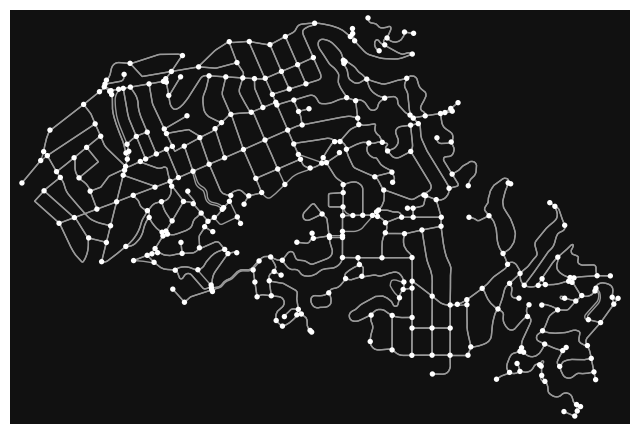

In [4]:
# download/model a street network for some city then visualize it
# G = ox.graph.graph_from_place("Nantes, France", network_type="drive")
G = ox.graph.graph_from_place("Piedmont, California, USA", network_type="drive")
fig, ax = ox.plot.plot_graph(G)

## Code

In [5]:
import csv
import re

# Assuming plots_dir is already defined in your script
input_file = plots_dir / "error.txt"
output_file = plots_dir / 'tmp.csv'

with open(input_file, 'r') as f_in, open(output_file, 'w', newline='') as f_out:
    writer = csv.writer(f_out)
    
    # Updated the header to reflect the new data
    writer.writerow(['Function', 'Time'])
    
    # This regex looks for 'INFO:root:' followed by the function name (letters/underscores)
    # then whitespace, and then the numeric time value.
    pattern = re.compile(r'INFO:root:([a-zA-Z_]+)\s+([\d\.]+)')
    
    for line in f_in:
        line = line.strip()
        
        # findall will extract all matches on a single line, even if they are squished together
        # It returns a list of tuples like: [('display', '93.89'), ('update_fleet', '0.02')]
        matches = pattern.findall(line)
        
        for func, time in matches:
            writer.writerow([func, time])

print(f"File successfully saved to {output_file}")

File successfully saved to /home/lucas/Documents/test/sim/notebooks/tmp.csv


In [6]:
def plot_time(df:pd.DataFrame, scale='ms'):
    display = df[df['Function']=='display']
    update = df[df['Function']=='update_fleet']
    if 'calculate_paths' in df['Function'].unique():
        # Using groupby cumcount is often safer than index // 3
        df['iteration'] = df.groupby('Function').cumcount()

        # 2. Pivot to wide format
        update = df.pivot(index='iteration', columns='Function', values='Time')

        # 3. Calculate update_time if necessary columns exist
        if 'calculate_paths' in update.columns and 'update_fleet' in update.columns:
            update['Time'] = update['calculate_paths'] + update['update_fleet']

    fig, axs = plt.subplots(1, 2, sharey=True, figsize=(12, 6))
    if scale=='ms':
        axs[0].plot(display['Time'])
        axs[1].plot(update['Time'])
    elif scale=='s':
        axs[0].plot(display['Time']/1000)
        axs[1].plot(update['Time']/1000)
    elif scale=='min':
        axs[0].plot(display['Time']/1000/60)
        axs[1].plot(update['Time']/1000/60)        

    axs[0].set_ylabel(f"Display Time ({scale})")
    axs[1].set_ylabel(f"Update Time ({scale})")

    axs[0].text(0.05, 0.95, f'Total time {display['Time'].sum()/1000:.2f}s',
                transform=axs[0].transAxes, fontsize=12, color='white', 
                bbox=dict(facecolor='black', alpha=0.5))
    axs[1].text(1.25, 0.95, f'Total time {update['Time'].sum()/1000:.2f}s',
                transform=axs[0].transAxes, fontsize=12, color='white', 
                bbox=dict(facecolor='black', alpha=0.5))

    plt.show()

# Shortest path calculation

In [7]:
cities=[
    "Lerm-et-musset, France",
    # "Piedmont, California, USA",
    # "Arcachon, France",
    # "Marmande, France",
    # "Pessac, France",
    # "Nice, France",
    # "Montpellier, France",
    # "Toulouse, France",
]

In [8]:
# df=pd.DataFrame(columns=['num_nodes', 'num_edges', 'basic_stats'], index=cities)
# file='res.csv'
# for city in tqdm(cities):
#     G = ox.graph.graph_from_place(city, network_type="drive")
#     df.loc[city]=G.number_of_nodes(), G.number_of_edges(), ox.basic_stats(G)
#     df.sort_values(by=['num_edges']).to_csv(file)
# df

In [9]:
def func():
    G = ox.graph.graph_from_place(city, network_type="drive")
    for u,v,k in G.edges:
        attrs_e = {(u, v, k): {
            'weight': 1, 
            }
        }
        nx.set_edge_attributes(G, attrs_e)
    rx_h=rx_helper(G)
    t1 = datetime.datetime.now()
    rx_h.get_all_shortest_paths()
    t2 = datetime.datetime.now()
    print((t2-t1))

    times.loc[city]=G.number_of_nodes(), G.number_of_edges(), str(t2-t1),''
    G.clear()

    times.sort_values(by=['num_edges']).to_csv(file)

file=Path('res_time.csv')
if file.exists():
    times=pd.read_csv(file, index_col=0)
else:
    times=pd.DataFrame(columns=['num_nodes', 'num_edges', 'time (s)', 'memory (MiB)'], index=cities)
for city in cities:
    %memit func()

0:00:00.003000


TypeError: Invalid value '' for dtype 'float64'

In [10]:
file=Path('res_time.csv')
times=pd.read_csv(file, index_col=0)
times['time (s)']=pd.to_timedelta(
    times['time (s)'], 
    # format='timedelta64[s]',
    # unit='s'
).dt.total_seconds()
times

,num_nodes,num_edges,time (s),memory (MiB)
"Lerm-et-musset, France",36,86,0.005643,6.33
"Piedmont, California, USA",352,944,1.245342,90.55
"Arcachon, France",686,1624,4.050297,490.13
"Marmande, France",1194,2624,10.291076,1474.68
"Pessac, France",2232,5135,39.792888,7218.12
"Nice, France",4017,8230,156.539300,21996.50
"Montpellier, France",5611,11955,412.033078,56077.27
"Toulouse, France",9296,19573,2095.282908,147853.41


### Time

num_edges time (s)
num_nodes time (s)
num_edges memory (MiB)
num_nodes memory (MiB)


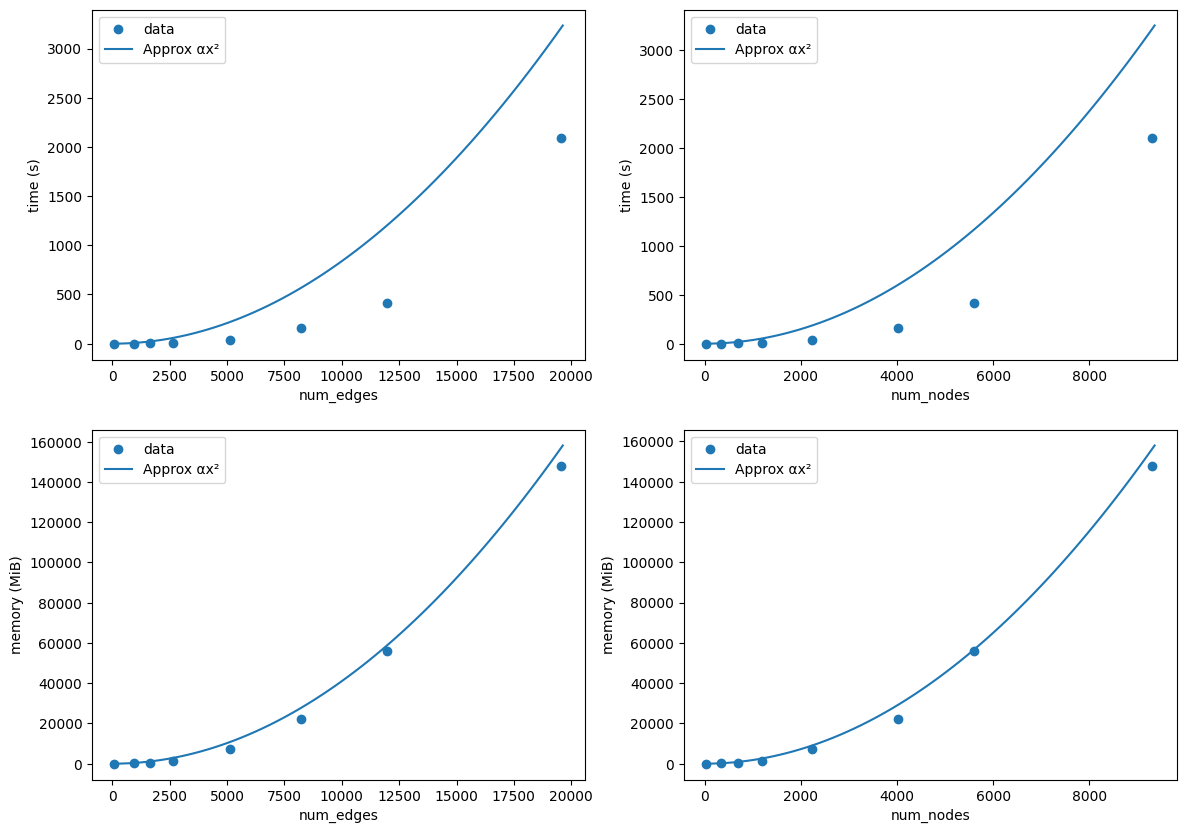

In [ ]:

fig, axs = plt.subplots(2,2, figsize=(14,10))

XS=['num_edges', 'num_nodes']
YS = ['time (s)', 'memory (MiB)']
for k,ax in enumerate(axs.flatten()):
    x, y = times[XS[k%2]], times[YS[k//2%2]]
    
    poly = np.polyfit(x, y, 2)
    polynomial = np.poly1d(poly)

    xs = np.linspace(x.min(), x.max()+60, len(x)+60)
    y_int = polynomial(xs)
    ys = [polynomial.coeffs[0]*x**2 for x in xs]

    ax.scatter(x, y, label='data')
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.plot(xs, ys, label='Approx αx²')
    # ax.plot(xs, y_int, '--', label='Fitted')
    ax.legend()
    ax.set_xlabel(XS[k%2])
    ax.set_ylabel(YS[k//2%2])

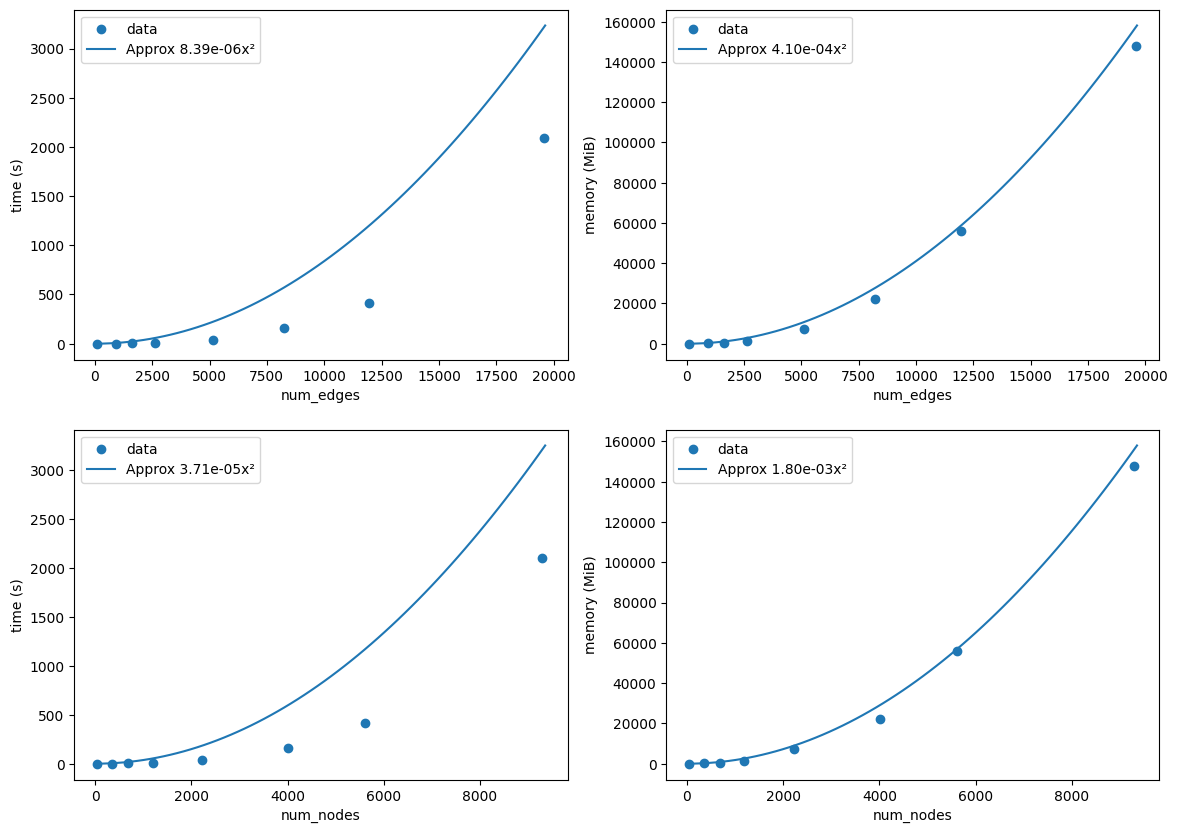

In [32]:
fig, axs = plt.subplots(2,2, figsize=(14,10))

XS=['num_edges', 'num_nodes']
YS = ['time (s)', 'memory (MiB)']
for k,ax in enumerate(axs.flatten()):
    x, y = times[XS[k//2%2]], times[YS[k%2]]
    
    poly = np.polyfit(x, y, 2)
    polynomial = np.poly1d(poly)

    xs = np.linspace(x.min(), x.max()+60, len(x)+60)
    y_int = polynomial(xs)
    ys = [polynomial.coeffs[0]*x**2 for x in xs]

    ax.scatter(x, y, label='data')
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.plot(xs, ys, label=f'Approx {polynomial.coeffs[0]:.2e}x²')
    # ax.plot(xs, y_int, '--', label='Fitted')
    ax.legend()
    ax.set_xlabel(XS[k//2%2])
    ax.set_ylabel(YS[k%2])

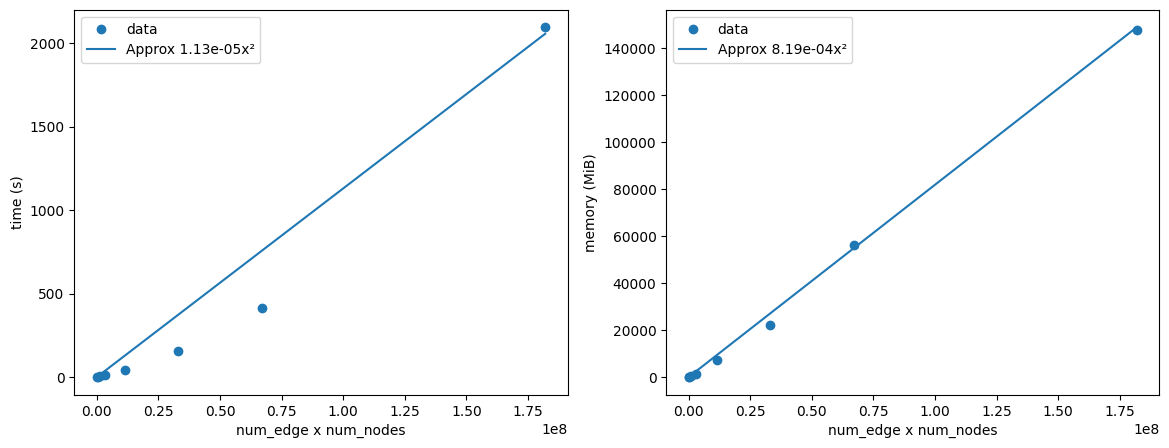

In [33]:
fig, axs = plt.subplots(1,2, figsize=(14,5))

YS = ['time (s)', 'memory (MiB)']
for k,ax in enumerate(axs.flatten()):
    x,y = times['num_edges']*times['num_nodes'], times[YS[k%2]]
    poly = np.polyfit(x, y, 1)
    polynomial = np.poly1d(poly)

    xs = np.linspace(x.min(), x.max()+60, len(x)+60)
    y_int = polynomial(xs)
    ys = [polynomial.coeffs[0]*x for x in xs]

    ax.scatter(x, y, label='data')
    # ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.plot(xs, ys, label=f'Approx {polynomial.coeffs[0]:.2e}x²')
    # ax.plot(xs, y_int, '--', label='Fitted')
    ax.legend()
    ax.set_xlabel('num_edge x num_nodes')
    ax.set_ylabel(YS[k%2])


# Number of cars

## Piedmont

### 100 voitures

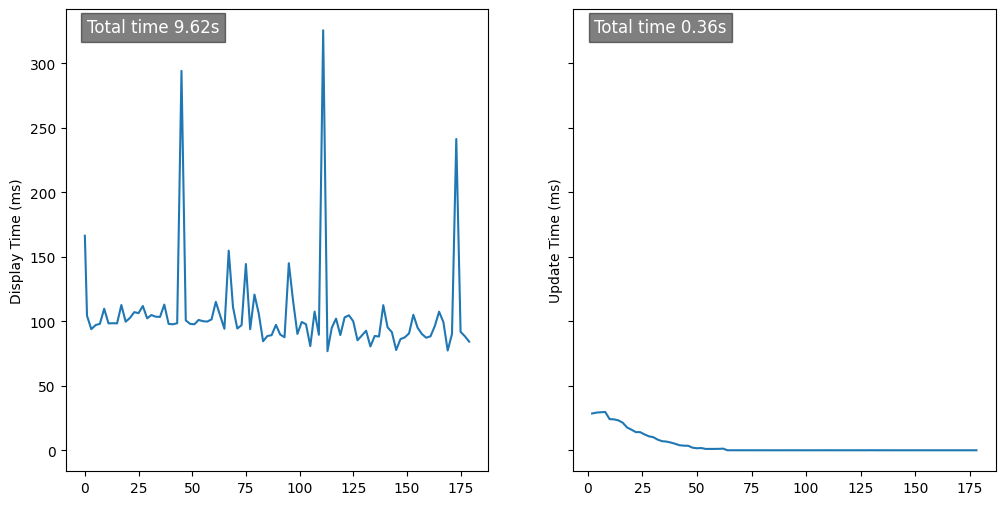

In [ ]:
df = pd.read_csv(data_dir / '100_voit.csv')
plot_time(df)

### 1000 voitures

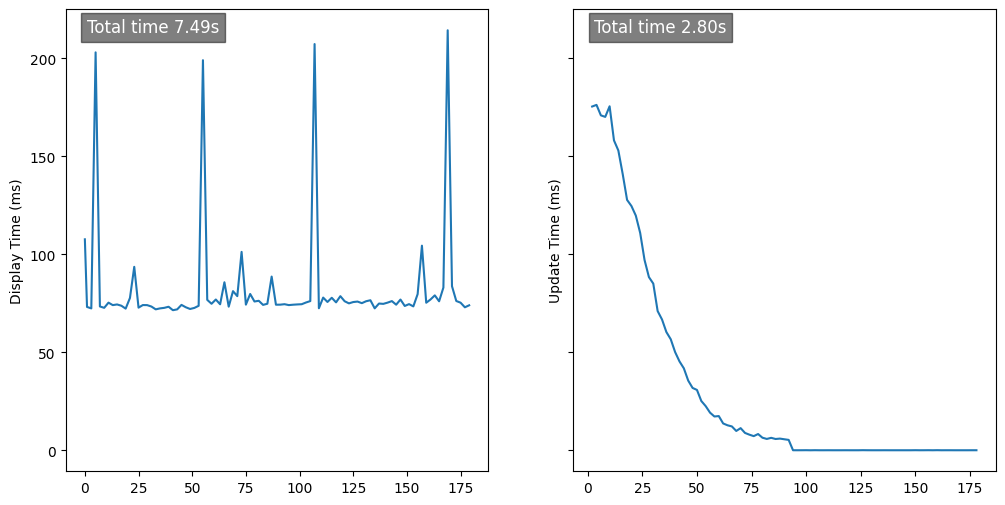

In [ ]:
df = pd.read_csv(data_dir / '1000_voit.csv')
plot_time(df)

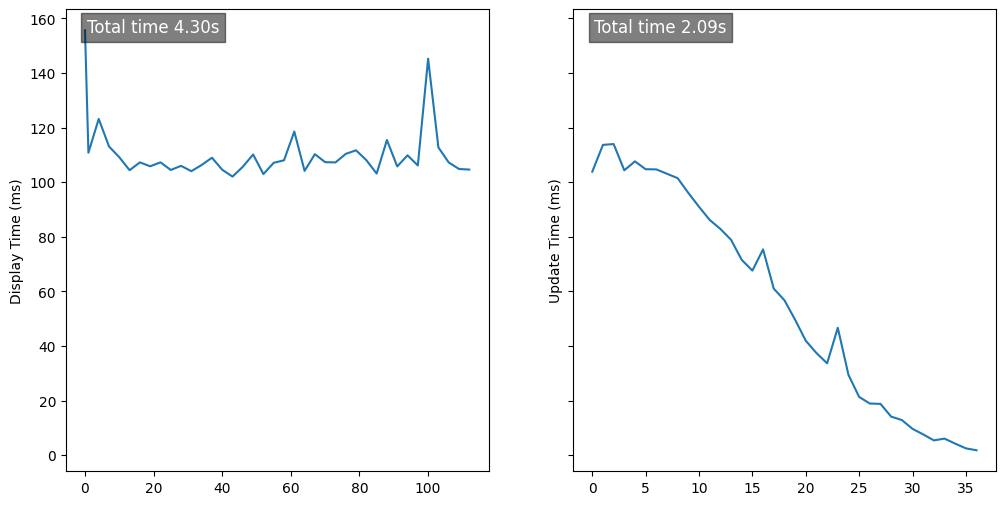

In [ ]:
df = pd.read_csv('tmp.csv')
plot_time(df)

### 10000 voit

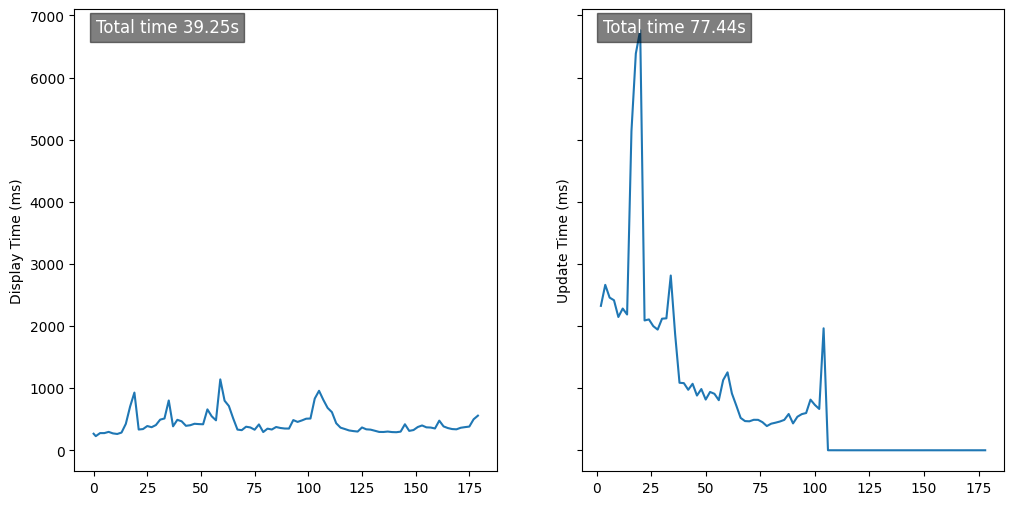

In [ ]:
df = pd.read_csv(data_dir / '10000_voit.csv')
plot_time(df)

## Nantes

### 10000 voitures

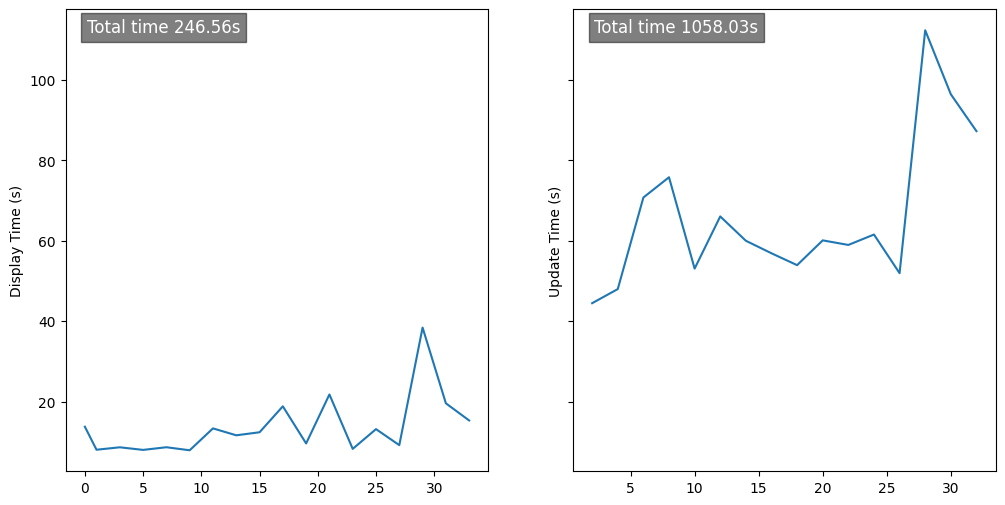

In [ ]:
df = pd.read_csv('tmp.csv')
plot_time(df, scale='s')